# One Uncertain Channel with High Investments

## 1. Descriptions
In this experiment, let's assume that we have known the performance of 3 out of 4 channels in the study with very high certainty. However, we are not quite sure about the performance of Channel 0, which is our biggest channel. Let's study how the Bayesian experimental design (BED) framework can help strengthen our knowledge and reduce our uncertainty.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import polars as pl
import polars.selectors as cs
from bedmmm.data.generator import DataGenerator
from bedmmm.experiment_designer import ExperimentDesigner
from bedmmm.model import MarketingMixModel

## 2. Synthetic Data Generation

In [6]:
np.random.seed(10)
generator = (
    DataGenerator(
        n_time_periods=52,  # weeks
        n_future_periods=4,
    )
    .generate_baseline(
        base=10,
        noise=0.0,
    )
    # Seasonality generated using sine wave
    .generate_control(
        control_effect=1,
        noise=1,
    )
    # 1. Low retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.2,
        saturation=5,
        shape=3,
        metric_lower_bound=3,
        noise=0.0,
    )
    # 2. Low retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.2,
        saturation=2,
        shape=1,
        noise=0.0,
    )
    # 3. High retention rate, high saturation, high shape
    .generate_media(
        retention_rate=0.8,
        saturation=6,
        shape=3.5,
        noise=0.0,
    )
    # 4. High retention rate, low saturation, low shape
    .generate_media(
        retention_rate=0.8,
        saturation=2,
        shape=1,
        noise=0.0,
    )
    .generate_target(noise=3)
)

data = generator.collect()
media_param_df, control_param_df = generator.get_parameters()

In [7]:
figure = px.line(
    data.with_row_index("time_index"),
    x="time_index",
    y=data.columns,
)
figure.show()

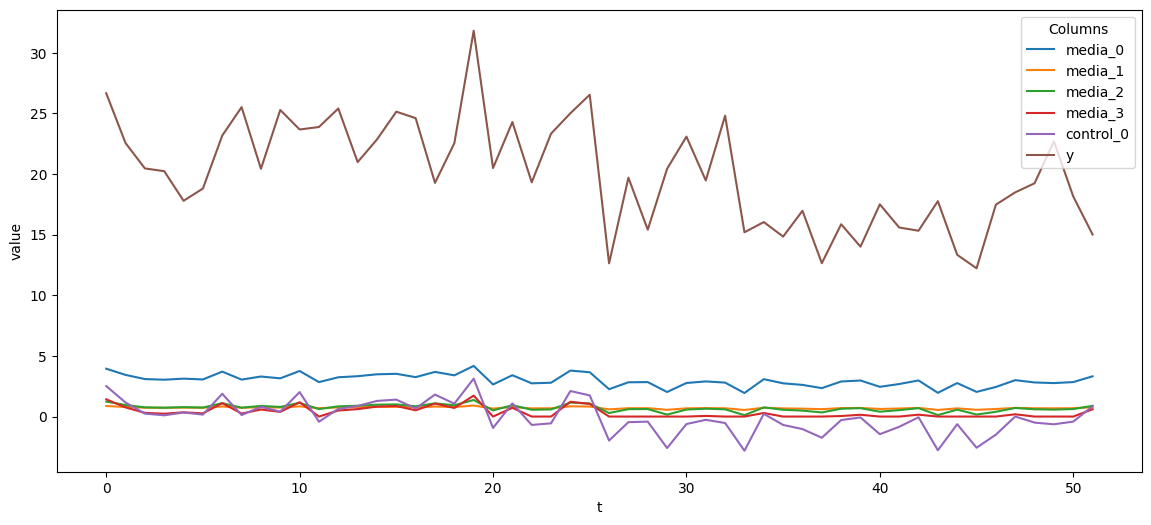

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

for column in data.columns:
    ax.plot(
        data.with_row_index("time_index")["time_index"],
        data[column],
        label=column,
    )

ax.set_xlabel("t")
ax.set_ylabel("value")
ax.legend(title="Columns")

plt.show()

## 3. Fit a Marketing Mix Model (MMM)

In [9]:
model_config = {
    #
    # Media channel 0 priors (high uncertainty)
    "retention_rate_lb_0": 0.1,
    "retention_rate_ub_0": 0.9,
    "shape_mu_0": 3,
    "shape_sigma_0": 2,
    "saturation_mu_0": 5,
    "saturation_sigma_0": 2,
    #
    # Media channel 1 priors (tight priors)
    "retention_rate_lb_1": 0.19,
    "retention_rate_ub_1": 0.21,
    "shape_mu_1": 1,
    "shape_sigma_1": 0.1,
    "saturation_mu_1": 2,
    "saturation_sigma_1": 0.1,
    #
    # Media channel 2 priors (tight priors)
    "retention_rate_lb_2": 0.79,
    "retention_rate_ub_2": 0.81,
    "shape_mu_2": 3.5,
    "shape_sigma_2": 0.1,
    "saturation_mu_2": 6,
    "saturation_sigma_2": 0.1,
    #
    # Media channel 3 priors (tight priors)
    "retention_rate_lb_3": 0.79,
    "retention_rate_ub_3": 0.81,
    "shape_mu_3": 1,
    "shape_sigma_3": 0.1,
    "saturation_mu_3": 2,
    "saturation_sigma_3": 0.1,
    #
    # Control
    "gamma_mu_0": 1.0,
    "gamma_sigma_0": 1.0,
    #
    # Baseline
    "baseline_mu": 10.0,
    "baseline_sigma": 0.1,
    #
    # Observation noise
    "obs_sigma": 3,
}
sampler_config = {
    "draws": 6_000,
    "tune": 3_000,
    "chains": 4,
    "cores": 4,
    "target_accept": 0.95,
}

model = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

In [10]:
idata = model.fit(
    data.drop(["y"]).to_pandas(),
    data["y"].to_pandas(),
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 3_000 tune and 6_000 draw iterations (12_000 + 24_000 draws total) took 49 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

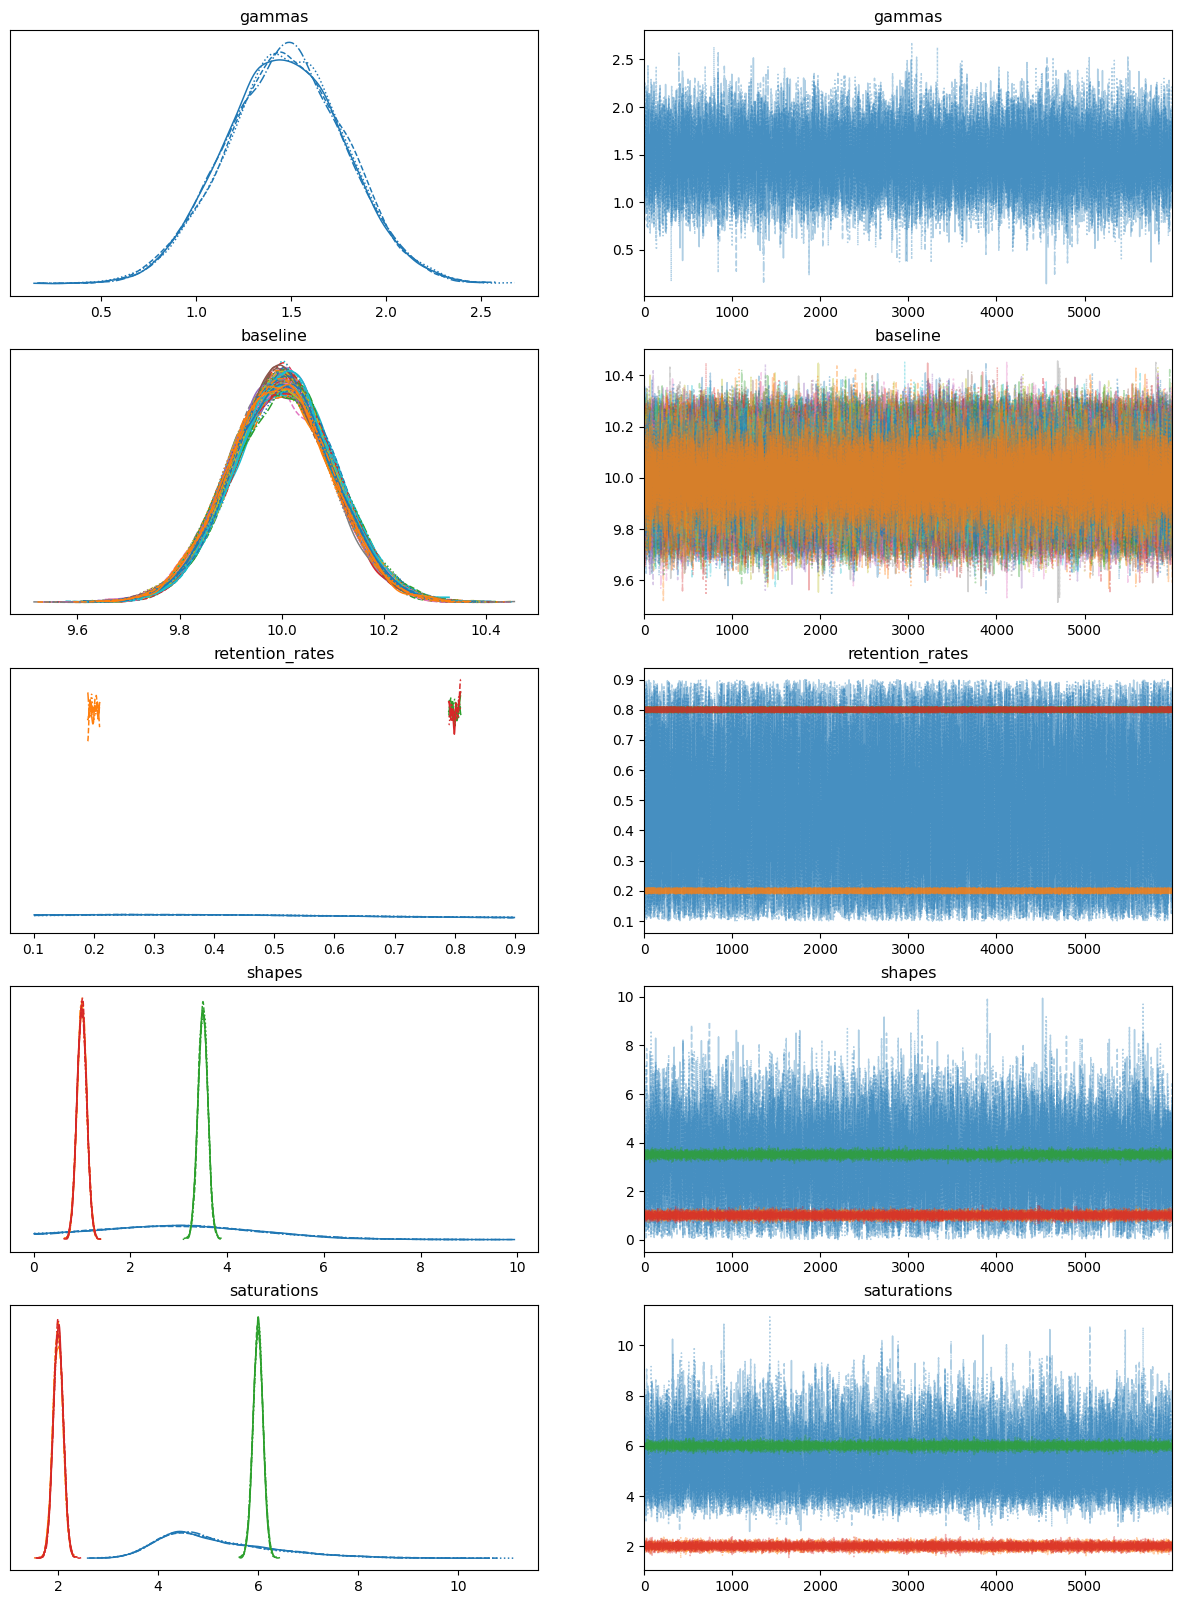

In [11]:
summary_df = az.summary(idata)
az.plot_trace(idata, figsize=(15, 20));

### 3.1 Comparison between Posterior Distributions and Ground Truth

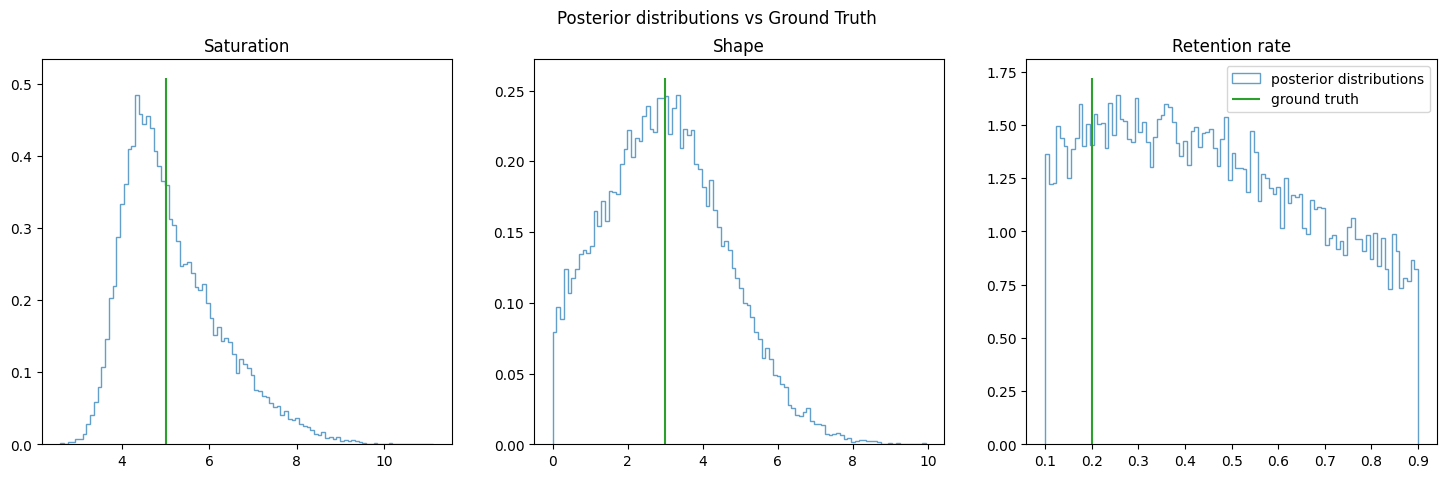

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for i, param in enumerate(["saturation", "shape", "retention_rate"]):
    ax[i].hist(
        idata.posterior[f"{param}s"].values[:, :, 0].flatten(),
        bins=100,
        density=True,
        histtype="step",
        alpha=0.7,
        label="posterior distributions",
    )
    ax[i].vlines(
        media_param_df.filter(pl.col("media_feature") == "media_0")[
            param
        ].item(),
        ymin=0,
        ymax=ax[i].get_ylim()[1],
        colors="C2",
        label="ground truth",
    )
    ax[i].set_title(f"{param.capitalize().replace('_', ' ')}")

plt.legend()
plt.suptitle("Posterior distributions vs Ground Truth")
plt.show()

## 4. Find the optimal experiment

When generating the synthetic data, a dataset, which we call "future data", is also generated along with the data used to fit the model above. "Future data" is not used to fit the model but considered as the budget planning for marketing investments. This helps us quantify the difference between the investments recommended in the optimal experiment and the planned budget (which the marketers are already comfortable of investing).

In [14]:
future_data = generator.collect(data_type="future")
future_control_vars = (
    future_data.slice(0, 1)
    .select(cs.starts_with("control_"))
    .to_numpy()
    .flatten()
)
future_media_data = (
    future_data.slice(0, 1)
    .select(cs.starts_with("media_"))
    .to_numpy()
    .flatten()
)

In [27]:
desginer = (
    ExperimentDesigner(n_media_channels=4, c=future_control_vars)
    .add_posterior_samples(idata)
    .configure_experiment_space(
        # Let's assume that we only do the experimnent on the Channel 0.
        lower_bound=np.concatenate([[0], future_media_data[1:]]),
        upper_bound=np.concatenate([[100], future_media_data[1:]]),
    )
    .configure_regularization(x_0=future_media_data)
)

In [28]:
d_hat = desginer.find_optimal_experiment()

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -0.008127643857069773
        x: [ 0.000e+00  7.669e-01  8.816e-01  5.920e-01]
      nit: 2
      jac: [ 1.178e-02        nan        nan        nan]
     nfev: 16
     njev: 8
 hess_inv: None


In [29]:
d_hat

array([0.        , 0.76685322, 0.88164121, 0.59196872])

## 5. Fit the MMM model with Experiment Data

In [30]:
generator_with_dhat = (
    generator.generate_new_observation(x=d_hat, c=future_control_vars)
    # .generate_new_observation(x=d_hat, c=np.array([1.0]))
    # .generate_new_observation(x=d_hat, c=np.array([1.0]))
    # .generate_new_observation(x=d_hat, c=np.array([1.0]))
    # .generate_new_observation(x=d_hat, c=np.array([1.0]))
    # .generate_new_observation(x=d_hat, c=np.array([1.0]))
)
data_with_dhat = generator_with_dhat.collect()

In [31]:
model_with_dhat = MarketingMixModel(
    model_config=model_config,
    sampler_config=sampler_config,
)

In [32]:
idata_with_dhat = model_with_dhat.fit(
    data_with_dhat.drop(["y"]).to_pandas(),
    data_with_dhat["y"].to_pandas(),
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [retention_rates, shapes, saturations, gammas, baseline]


Output()

Sampling 4 chains for 3_000 tune and 6_000 draw iterations (12_000 + 24_000 draws total) took 45 seconds.
Sampling: [baseline, gammas, retention_rates, saturations, shapes, y]
Sampling: [y]


Output()

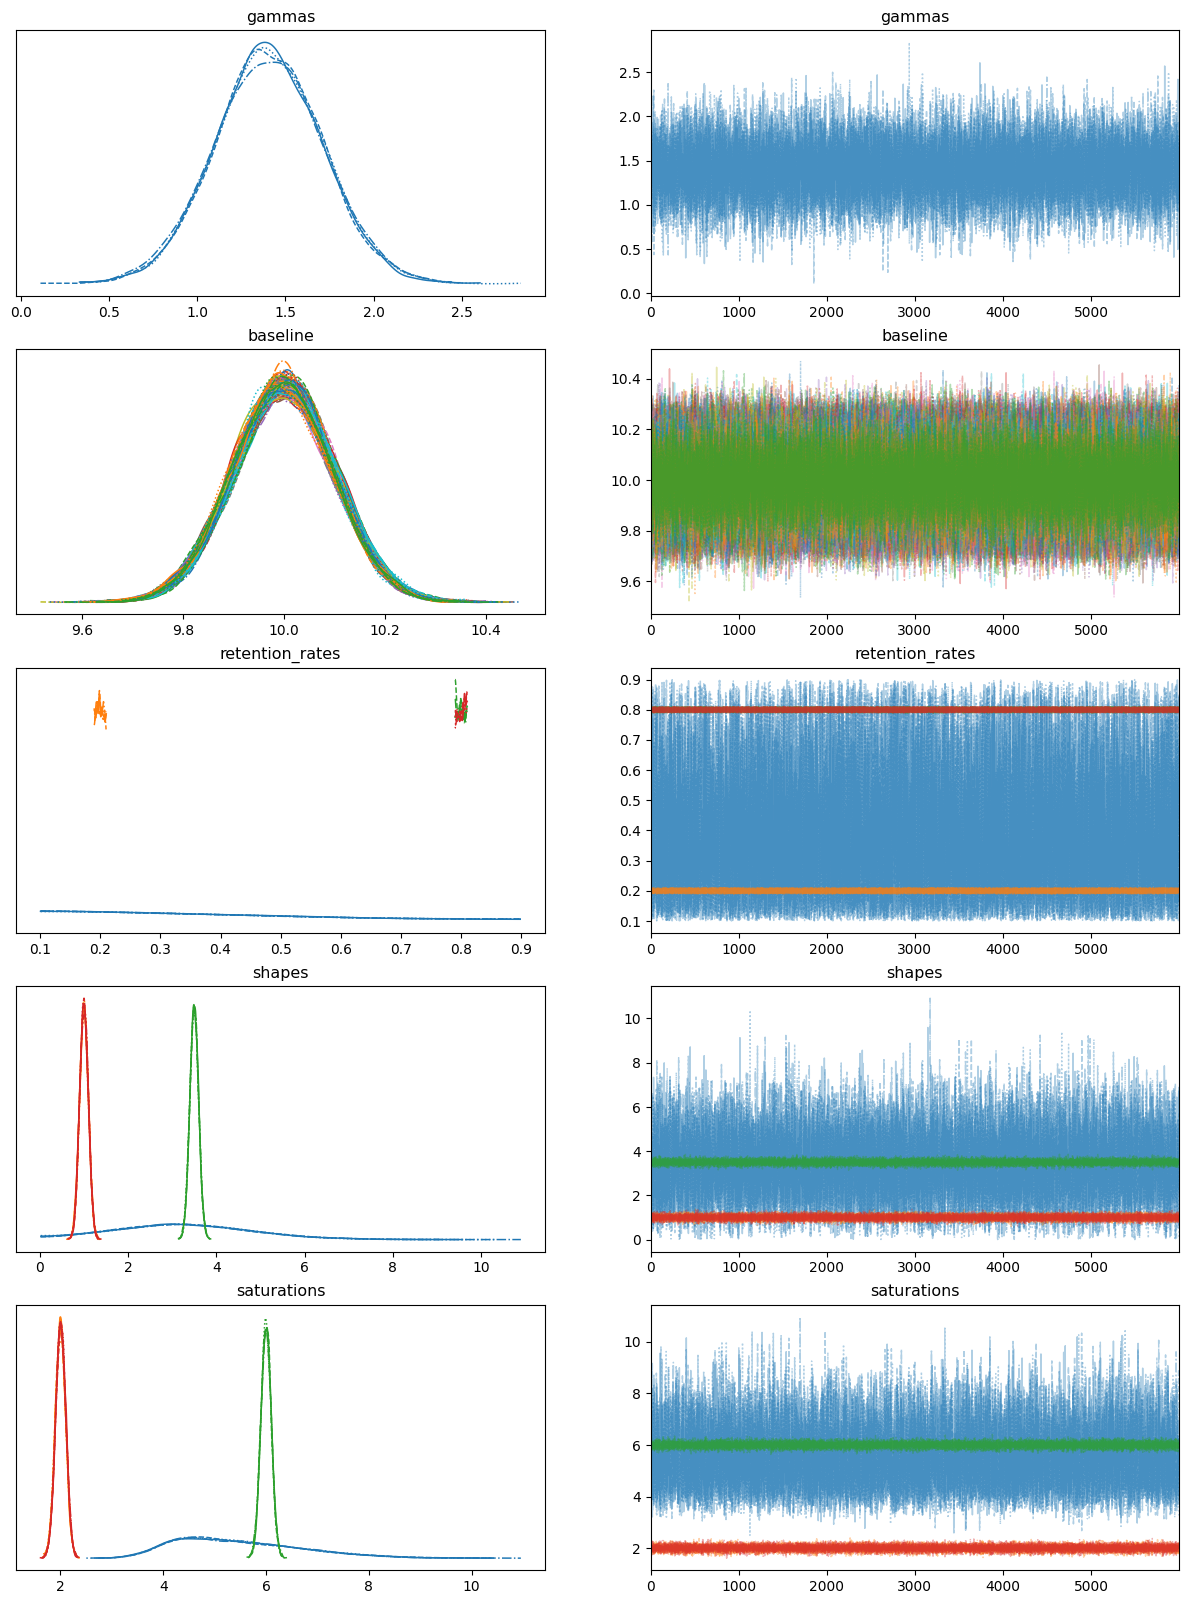

In [33]:
summary_with_dhat_df = az.summary(idata_with_dhat)
az.plot_trace(idata_with_dhat, figsize=(15, 20));

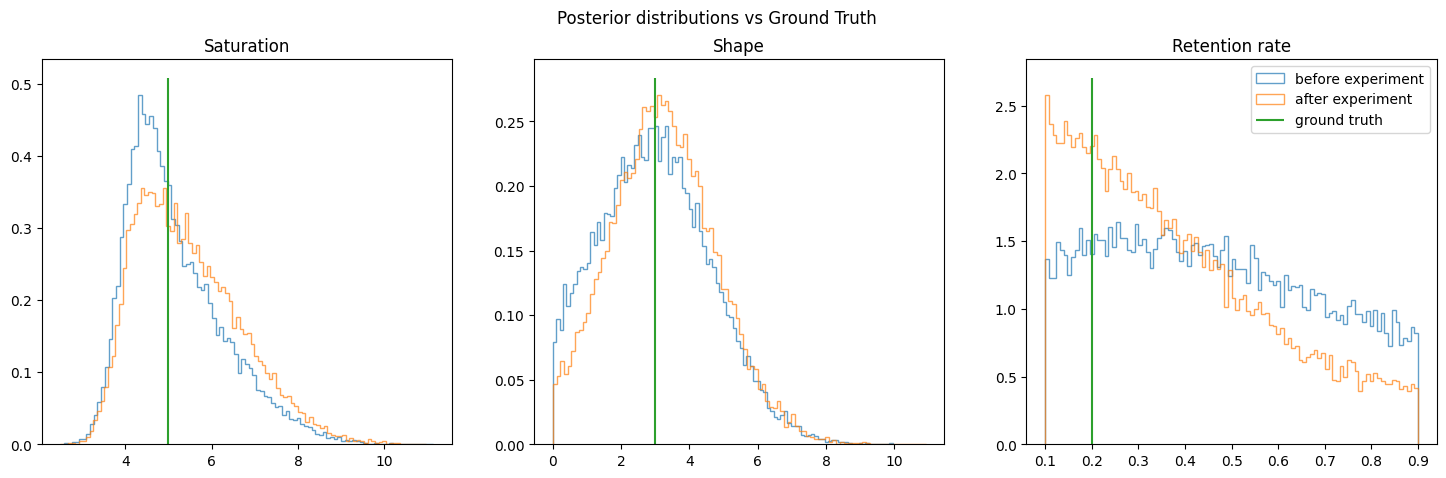

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for i, param in enumerate(["saturation", "shape", "retention_rate"]):
    ax[i].hist(
        idata.posterior[f"{param}s"].values[:, :, 0].flatten(),
        bins=100,
        density=True,
        histtype="step",
        alpha=0.7,
        label="before experiment",
    )
    ax[i].hist(
        idata_with_dhat.posterior[f"{param}s"].values[:, :, 0].flatten(),
        bins=100,
        density=True,
        histtype="step",
        alpha=0.7,
        color="C1",
        label="after experiment",
    )
    ax[i].vlines(
        media_param_df.filter(pl.col("media_feature") == "media_0")[
            param
        ].item(),
        ymin=0,
        ymax=ax[i].get_ylim()[1],
        color="C2",
        label="ground truth",
    )
    ax[i].set_title(f"{param.capitalize().replace('_', ' ')}")

plt.legend()
plt.suptitle("Posterior distributions vs Ground Truth")
plt.show()